# Example of data import from OmniSegger output, processing, and curation, for single-cell analysis

__Steps__:
1. Download zip folder for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7753_CecA_1uM_rep1.zip'
2. First, we implement 'import_processing_code.py' to apply background subtraction, extract single-cell linking data from Omnisegger output (stored in the /cell folder). This script will generate dataframes with extracted cell features and cell information overtime, and dictionaries with all cropped single-cell channels
3. Then, we curate trajectories using 'post_processing_curation_functions.py' functions and finally export the curated dataframes that will be used for downstream analysis

__Requirements on how to run__:
1. This notebook assumes the OmniSegger-processed extracted file data folder, here 'CJW7753_CecA_1uM_rep1', lives in the same folder as the notebook
2. The function libraries 'analysis_functions_library.py' and 'post_processing_curation_functions.py' are pulled from the repository folder '2_singlecell_microwells'

__Code underlying data and figures__:
- Single-cell data in PDMS microwells, strains CJW7845, CJW7753, and MG1655 (+fluor AMPs)
- Figures 1-4, S2-S7

### 1. Run 'import_processing_code.py'

Run time: < 1hr per position, depends on amount of detected cells form OmniSegger

In [1]:
# -*- coding: utf-8 -*-
"""
Code for single-cell analysis for images processed by SuperSegger-Omnipose :
1) Imports cell arrays output from SuperSegger, containing cell masks, cropped channels, cell_ids, bounding boxess (https://github.com/wiggins-lab/SuperSegger/wiki/The-cell-data-files)
2) Apply background subtraction (Adapted from Papagiannakis et al., 2025) to fluorescence channels (full images)
3) Goes through each cell file output from Supersegger, extracts cell info, coordinates of the bounding box (cropped cell image), computes statistics using Omnipose masks, 
    computes masks for fluorescence channels (e.g. nucleoid, ribosomes), correlation (SCF) between the different channels

Output: 
- Dictionary with cropped images for each cell, at each frame, for all channels (phase, fluor1, fluor2, ...) and corresponding masks
- Dictionary of cell information, e.g. birth, death, division, as estimated by SuperSegger 
- Dataframe of cell features, e.g. area, time, mean fluorescences, correlations. Only 'static' features are estimated here based on the single frame - kinetic parameters, e.g. growth rate, are computed later on.
    
@author: alessio fragasso
Tue Mar 25 18:02:23 2025
"""
# import modules
import sys
import skimage
from scipy import io
import os
import re
import gc
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch
import keyboard
import time
import cupy as cp
import json
import pickle
from scipy.interpolate import splprep, splev, splrep, interp1d, UnivariateSpline, BSpline
from scipy.signal import lfiltic, lfilter, savgol_filter
from scipy.stats import spearmanr
from skimage import graph, morphology, measure
import imageio.v3 as iio
import imageio
from scipy.ndimage import gaussian_filter, gaussian_filter1d, binary_fill_holes, binary_closing, binary_opening, center_of_mass
from scipy import ndimage
from PIL import Image as im
from skimage.morphology import skeletonize
from skimage.morphology import binary_closing
from skimage.filters import threshold_otsu, threshold_local
from skimage.segmentation import find_boundaries
from skimage import measure, morphology
from numpy.lib.stride_tricks import as_strided
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA Available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

# decide which GPU to use
cp.cuda.Device(0).use()   
"""
Import analysis functions library
"""
import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells").resolve()))
from analysis_functions_library import *

'''
Input global variables
'''
fr = 1    # [min] time between frame
px_size = 0.065841  # um/px   (pixel size, 100x)
px_erode = 4                # number of pixels to erode in the cell mask to identify ROI for correlation
offs_x = 10                # distance from image edges to exclude from analysis
offs_y = 10
save = True
bkg_sub = True
show = False

pos_list = create_pos_list(1, 20, double_digit = True) 
ch_list = ['phase', 'fluor1', 'fluor2','fluor3']
ch_fluor_list = [s for s in ch_list if 'fluor' in s]
 
experiment_path = "CJW7753_CecA_1uM_rep1"     # -> extracted from CJW7753_CecA_1uM_rep1/
exp_name = experiment_path   # usual exp_name format is 'Strain_AMP_concentration_replicate#'
rep_name = 'rep1
# read fr_inj from the notes 
notes_file = next(Path(experiment_path).glob("notes_*.txt"))
print(notes_file.read_text())   # check when AMP was injected 'frame xx/yy'

Device: cuda
CUDA Available: True
Number of GPUs: 2
Exp1) 241009, CJW7753 (0.2% arabinose, overnight)

37degC, M9GluCAAT (0.2% Glu, 0.4% CAA)

During acquisition: only 0.2% arabinose

CellTak:
- 50uL, 5min, of CellTak. 3x MQ wash.
- 0.5uL, OD=0.1, 5min, in M9GluCAAT. Quick medium wash.


Treatments/pos:
xy07-09: CJW7753 + CecA 1uM --> injected at frame 21/22

Comments:
- Good



In [8]:
fr_inj = 21   # <-- set AMP injection frame from what you see printed above, with the convention of using the frame right prior injection as the frame of injection.

In [10]:
count=0
for pos in pos_list:
    '''
    Get paths to all folders
    '''
    
    folder_path = experiment_path + '/' +\
        pos
    cells_path = folder_path+"/cell"
    mask_path = folder_path + '/masks'
    
    pos_num = re.findall(r'\d+', pos)[0]
    if not os.path.exists(cells_path):
        continue
    elif len(os.listdir(cells_path))==0:
        continue
    cells_list = os.listdir(cells_path)
    print(pos)
    if os.path.exists(mask_path):
        masks_list = os.listdir(mask_path)

    paths_dict = {}
    file_list_dict = {}
    
    for ch in ch_list:   
        paths_dict[ch] = folder_path + '/'+ ch
        file_list_dict[ch] = os.listdir(paths_dict[ch])
            
    phase_list =file_list_dict['phase']
    phase_path = paths_dict['phase']

    '''
    Initialize dictionaries and lists
    '''
    cell_stack_dict = {}  # dictionary of cells parameters over time
    cell_ch_dict = {}  # dictionary of cells phase and mask over time
    cell_info_dict = {}   # dictionary of cell info: birth frame (starts from 1), death frame, divide or not, motherID, sisterID, daughterID
    cell_features_all_df = pd.DataFrame()   

    '''Subtract background from fluorescence images and store in temporary dictionaries'''
    fluor_bkg_sub_dict = {}
    fluor_mask_dict = {}
    mask_dict = {}
    phase_dict = {}
    
    img_size = {}
    for ch in ch_fluor_list:
        if bkg_sub:
            print('..Subtract background for channel ' + ch + ' at pos ' + pos + ' for experiment '+ exp_name)
            fluor_list = file_list_dict[ch]
            fluor_path = paths_dict[ch]
            for k in range(len(fluor_list)):
                if k%20==0: 
                    print(k)
                mask_temp = iio.imread(mask_path+'/'+masks_list[k])
                phase_temp = iio.imread(phase_path+'/'+phase_list[k])
                fluor_temp = iio.imread(fluor_path + '/' + fluor_list[k])
                
                # start = time.time()
                bs = int(fluor_temp.shape[0]/16)
                fluor_bkg_sub, fluor_bkg, fluor_median_bkg = local_bkg_sub_cp(
                    fluor_temp, mask_temp, pos, exp_name, frame=str(k), box_size=bs, dilations=15, sigma_=60, show=False)
                
                fluor_bkg_sub_dict[(ch,k)] = fluor_bkg_sub
                fluor_mask = get_fluor_mask(fluor_bkg_sub,parameters=[2.5,0.95])
                
                fluor_mask_dict[(ch,k)] = fluor_mask
                mask_dict[k] = mask_temp
                phase_dict[k] = phase_temp
                img_size[k] = mask_temp.shape


    print('..Analyzing cells at pos ' + pos + ' for experiment '+ exp_name)
    cell_count = 0
    for cell in cells_list:
        
        cell_id = cell[:11] + '_'+pos + '_' +exp_name
        
        C = io.loadmat(cells_path+'/'+cell)                         # dictionary with all meshes and fluor stats for one cell over time
       
        ### get cell info and store in cell_dict
        birth = int(C['birth'].flatten()[0])
        if birth>len(masks_list)-5:
            continue
        
        
        if cell_count%50 == 0 :
           print('..Extracting data from '+cell_id + ', cell count = ' + str(cell_count))
        cell_count +=1
        death = C['death'].flatten()[0]
        divide = C['divide'].flatten()[0]
        motherID = C['motherID'].flatten()[0]
        sisterID = C['sisterID'].flatten()[0]
        daughterID = C['daughterID'].flatten()
        cell_info_dict[cell_id] = birth, death, divide, motherID, sisterID, daughterID
        
        # get cell stack and go through it
        cell_stack = dict(enumerate(C['CellA'].flatten(), 1))
        cell_stack_dict[cell_id] = cell_stack
        area_list=[]
        frame_list=[]
        cell_BB = []
        edge_flag_list=[]
        SCF_f12_list = []
        SCF_f13_list = []
        SCF_f23_list = []
        daughterID_list = []
        fluor_temp = {}
        mean_int_df = pd.DataFrame()
        fluor_mask_df = pd.DataFrame()
        for i in cell_stack:
            frame = i-2+birth
            cropped_ch_dict = {}
            mean_temp_df = pd.DataFrame()
            fluor_mask_temp_df = pd.DataFrame()
            cell_edge = False
            # print(i)
            cell_stack_temp = cell_stack[i]
            cropped_mask = cell_stack_temp['mask'][0][0]
            cropped_phase = cell_stack_temp['phase'][0][0]
            mask_temp = mask_dict[frame]
            phase_temp = phase_dict[frame]
            A, rcm, r_off, angle, x1, x2, y1, y2, edge_flag = get_cell_coordinates(cell_stack[i])      
            # print('Angle of inclination is: ' + str(angle))
            cropped_mask_2 = mask_temp[y1:y2, x1:x2]
            cropped_phase_2 = phase_temp[y1:y2, x1:x2]
            if bkg_sub:
                for ch in ch_fluor_list:
                    fluor_bs_temp = fluor_bkg_sub_dict[(ch,frame)]
                    img_y, img_x = fluor_bs_temp.shape
                    if x1 < offs_x or y1 < offs_y or x2 > img_x-offs_x or y2 > img_y-offs_y:
                        cell_edge = True
                        break
                    else: 
                        cropped_ch_dict[ch] =  fluor_bs_temp[y1:y2, x1:x2]
                        fluor_mask = fluor_mask_dict[(ch,frame)][y1:y2, x1:x2]
                        fluor_mask_cropped = fluor_mask*cropped_mask
                        cropped_ch_dict['mask_'+ch] = fluor_mask_cropped
                        if np.sum(fluor_mask_cropped>0)>0:
                            fluor_mask_temp_df['mean_mask_'+ch] = pd.Series(np.mean(cropped_ch_dict[ch][fluor_mask_cropped>0]))   
                            fluor_mask_temp_df['area_mask_'+ch] = pd.Series(np.sum(fluor_mask_cropped>0))
                            fluor_mask_temp_df['area_mask_ratio_'+ch] = pd.Series(np.sum(fluor_mask_cropped>0)/np.sum(cropped_mask>0))
                            # print(str(fluor_mask_df))
                        else:
                            fluor_mask_temp_df['mean_mask_'+ch] = pd.Series(0)
                            fluor_mask_temp_df['area_mask_'+ch] =  pd.Series(0)
                            fluor_mask_temp_df['area_mask_ratio_'+ch] = pd.Series(0)
                        mean_temp_df['mean_'+ch] = pd.Series(np.mean(cropped_ch_dict[ch][cropped_mask>0]))      
                        # print(str(mean_temp_df))
            else:
                for ch in ch_fluor_list:
                    cropped_ch_dict[ch] =  cell_stack_temp[ch][0][0]
                    mean_temp_df['mean_'+ch] = pd.Series(np.mean(cropped_ch_dict[ch][cropped_mask>0]))
                    
            if cell_edge:
                break
            
            cropped_ch_dict['mask'] = cropped_mask
            cropped_ch_dict['phase'] = cropped_phase
            mean_temp_df['mean_phase'] =  pd.Series(np.mean(cropped_ch_dict['phase'][cropped_mask>0]))   
            

            if show:
                contours = measure.find_contours(cropped_mask, level=0.5)
                countours_fluor1 = measure.find_contours(fluor_mask_cropped, level=0.5)
                
            
                fig = plt.figure(figsize=(10,5))
                plt.suptitle(cell_id + ' at frame ' + str(frame))
                ax1 = fig.add_subplot(2,3,1)
                plt.imshow(cropped_phase)
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0],
                                  linewidth=2, color='yellow')
                fig.add_subplot(2,3,2)
                plt.imshow(cropped_mask)
                ax1 = fig.add_subplot(2,3,3)
                plt.imshow(cropped_ch_dict['fluor1'])
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0],
                                  linewidth=2, color='yellow')
                        
                ax1 = fig.add_subplot(2,3,4)
                plt.imshow(cropped_phase_2)
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0],
                                  linewidth=2, color='yellow')
                ax1 = fig.add_subplot(2,3,5)
                plt.imshow(cropped_mask_2)
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0],
                                  linewidth=2, color='yellow')
                ax1 = fig.add_subplot(2,3,6)
                plt.imshow(cropped_ch_dict['fluor2'])
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0],
                                  linewidth=2, color='yellow')
                plt.show()
            
            
            mask_eroded = ndimage.binary_erosion(cropped_mask, iterations=px_erode)     # ROI for SCF: erode mask by px_erode px
            mask_eroded_3 = ndimage.binary_erosion(cropped_mask, iterations=px_erode+1) # ROI for cytoplasm

            phase_roi = cropped_ch_dict['phase'][mask_eroded > 0].ravel()
            fluor1_roi = cropped_ch_dict[ch_fluor_list[0]][mask_eroded > 0].ravel()
            fluor2_roi = cropped_ch_dict[ch_fluor_list[1]][mask_eroded > 0].ravel()
            fluor3_roi = cropped_ch_dict[ch_fluor_list[2]][mask_eroded > 0].ravel()
            SCF_f12, _ = spearmanr(fluor1_roi, fluor2_roi)
            SCF_f13, _ = spearmanr(fluor1_roi, fluor3_roi)
            SCF_f23, _ = spearmanr(fluor2_roi, fluor3_roi)

            SCF_f12_list.append(SCF_f12)
            SCF_f13_list.append(SCF_f13)
            SCF_f23_list.append(SCF_f23)

            '''Periplasm vs cytoplasm ROIs and mean signals'''
            mask_peri = cropped_mask * np.logical_not(mask_eroded_3)   # periplasm = full mask minus eroded interior
            mask_cyto = mask_eroded_3.copy()                          # cytoplasm = eroded interior

            for ch in ch_fluor_list:
                peri_vals = cropped_ch_dict[ch][mask_peri > 0].ravel()
                cyto_vals = cropped_ch_dict[ch][mask_cyto > 0].ravel()
                mean_peri = np.mean(peri_vals)
                mean_cyto = np.mean(cyto_vals)
                mean_temp_df['mean_'+ch+'_peri']   = pd.Series(mean_peri)
                mean_temp_df['mean_'+ch+'_cyto']   = pd.Series(mean_cyto)
                mean_temp_df['median_'+ch+'_cyto'] = pd.Series(np.median(cyto_vals))
                mean_temp_df[ch+'_peri_cyto_diff']  = pd.Series(mean_peri - mean_cyto)
                mean_temp_df[ch+'_peri_cyto_ratio'] = pd.Series(mean_peri / mean_cyto)
            
            
            cell_ch_dict[(cell_id, frame)] = cropped_ch_dict, cell_stack[i]
            area = np.size(np.where(cropped_mask>0)[0])
            daughterID_list.append(daughterID)
            edge_flag_list.append(edge_flag)
            frame_list.append(frame)
            area_list.append(area)
            cell_BB.append((x1,x2,y1,y2))
            mean_int_df = pd.concat([mean_int_df,mean_temp_df]).reset_index(drop=True)
            fluor_mask_df = pd.concat([fluor_mask_df ,fluor_mask_temp_df]).reset_index(drop=True)
 
        cell_features_df = pd.DataFrame()
        cell_features_df['frame'] = frame_list
        cell_features_df['time_min'] = [fr*s for s in frame_list]
        cell_features_df['area'] = area_list
        cell_features_df['cell_id'] = cell_id
        cell_features_df['exp'] = exp_name
        cell_features_df['rep'] = rep_name
        cell_features_df['xy'] = pos_num
        cell_features_df['fr_inj'] = fr_inj
        cell_features_df['BB'] = cell_BB
        cell_features_df['birth'] = birth
        cell_features_df['death'] = death
        cell_features_df['motherID'] = motherID
        cell_features_df['sisterID'] = sisterID
        cell_features_df['daughterID'] = daughterID_list
        cell_features_df['daughters'] = len(daughterID)
        cell_features_df['edge_flag'] = edge_flag_list
        cell_features_df['bkg_sub'] = bkg_sub
        cell_features_df = pd.concat([cell_features_df, mean_int_df], axis=1)
        cell_features_df = pd.concat([cell_features_df, fluor_mask_df], axis=1)
        cell_features_df['SCF_f12'] = SCF_f12_list
        cell_features_df['SCF_f13'] = SCF_f13_list
        cell_features_df['SCF_f23'] = SCF_f23_list
            
        cell_features_all_df = pd.concat([cell_features_all_df,cell_features_df])
        
    if save and len(cell_features_all_df)>0:
        if bkg_sub:
            cell_ch_dict_name = pos + '_' + exp_name + '_cell_ch_bkg_sub'
        else: cell_ch_dict_name = pos + '_' + exp_name  + '_cell_ch'
        cell_info_dict_name = pos + '_' + exp_name + '_cell_info'
        df_basename = pos + '_' + exp_name +'_cell_features_df'
        save_dict_path = experiment_path + '/output'
        if not os.path.exists(save_dict_path):
            os.makedirs(save_dict_path)
        dict_cell_path = os.path.join(save_dict_path, cell_ch_dict_name+'.pkl')
        cell_info_path = os.path.join(save_dict_path, cell_info_dict_name+'.pkl')
        with open(dict_cell_path, 'wb') as pickle_file:
            pickle.dump(cell_ch_dict, pickle_file)
        with open(cell_info_path, 'wb') as pickle_file:
            pickle.dump(cell_info_dict, pickle_file)
        cell_features_all_df.to_pickle(save_dict_path+'/'+df_basename+'.pkl')
        count += len(cell_features_all_df['cell_id'].unique())
        print('At position '+pos+' there are ' +
              str(len(cell_features_all_df['cell_id'].unique()))+' cells')
        
        del cell_ch_dict
        gc.collect()

print('In total there are '+
      str(count)+' cells')            
                
                

xy07
..Subtract background for channel fluor1 at pos xy07 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Subtract background for channel fluor2 at pos xy07 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Subtract background for channel fluor3 at pos xy07 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Analyzing cells at pos xy07 for experiment CJW7753_CecA_1uM_rep1
..Extracting data from cell0000001_xy07_CJW7753_CecA_1uM_rep1, cell count = 0
..Extracting data from cell0000051_xy07_CJW7753_CecA_1uM_rep1, cell count = 50
At position xy07 there are 87 cells
xy08
..Subtract background for channel fluor1 at pos xy08 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Subtract background for channel fluor2 at pos xy08 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Subtract background for channel fluor3 at pos xy08 for experiment CJW7753_CecA_1uM_rep1
0
20
40
60
80
100
120
..Analyzing cells at pos xy08 for experiment CJW7753_CecA_

__Output:__ 
- Per-position cell features dataframes, ending with '_cell_features_df'
- Per-position dictionaries containing cropped single cell images of all background subtracted channels + Omnipose masks
- Per-position dictionary containing cell info from SuperSegger linking (e.g. birth frame, motherID, etc)

All saved in /output folder in the same directory

## 2. Perform curation using 'post_processing_curation_functions.py' library (<10 min)

Run time: < 10min

__Import curation and growth rate calculation functions__

In [2]:
"""
Import post-processing functions library
"""
import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells").resolve()))
from post_processing_curation_functions import *

__Import cell features dataframes generated at step 1__

In [3]:
import glob

output_path = experiment_path + '/output'
df_files = sorted(glob.glob(output_path + '/*cell_features_df*.pkl'))

cell_features_all_df = pd.DataFrame()
cell_id_list = []
for f in df_files:
    df = pd.read_pickle(f)
    if len(df) == 0:
        continue
    df['area_um'] = df['area'] * px_size**2          # add_features_growth expects this
    df = add_features_growth(df, fr)
    cells = df['cell_id'].unique().tolist()
    print('Loaded N=' + str(len(cells)) + ' cells from ' + os.path.basename(f))
    cell_features_all_df = pd.concat([cell_features_all_df, df])
    cell_id_list += cells

df = cell_features_all_df.copy()
print('Total: ' + str(len(cell_id_list)) + ' cells')

Loaded N=87 cells from xy07_CJW7753_CecA_1uM_rep1_cell_features_df.pkl
Loaded N=68 cells from xy08_CJW7753_CecA_1uM_rep1_cell_features_df.pkl
Loaded N=65 cells from xy09_CJW7753_CecA_1uM_rep1_cell_features_df.pkl
Total: 220 cells


__Perform basic global curation__

In [5]:
df = curate_short_trajectories(df, 20)    # eliminate too short trajectories < 20 frames
df = curate_fast_jumps(df, gr_max=0.04, gr_min=-0.04) # eliminates cells with impossible growth rates

__Plot raw trajectories (area, normalized growth rate)__

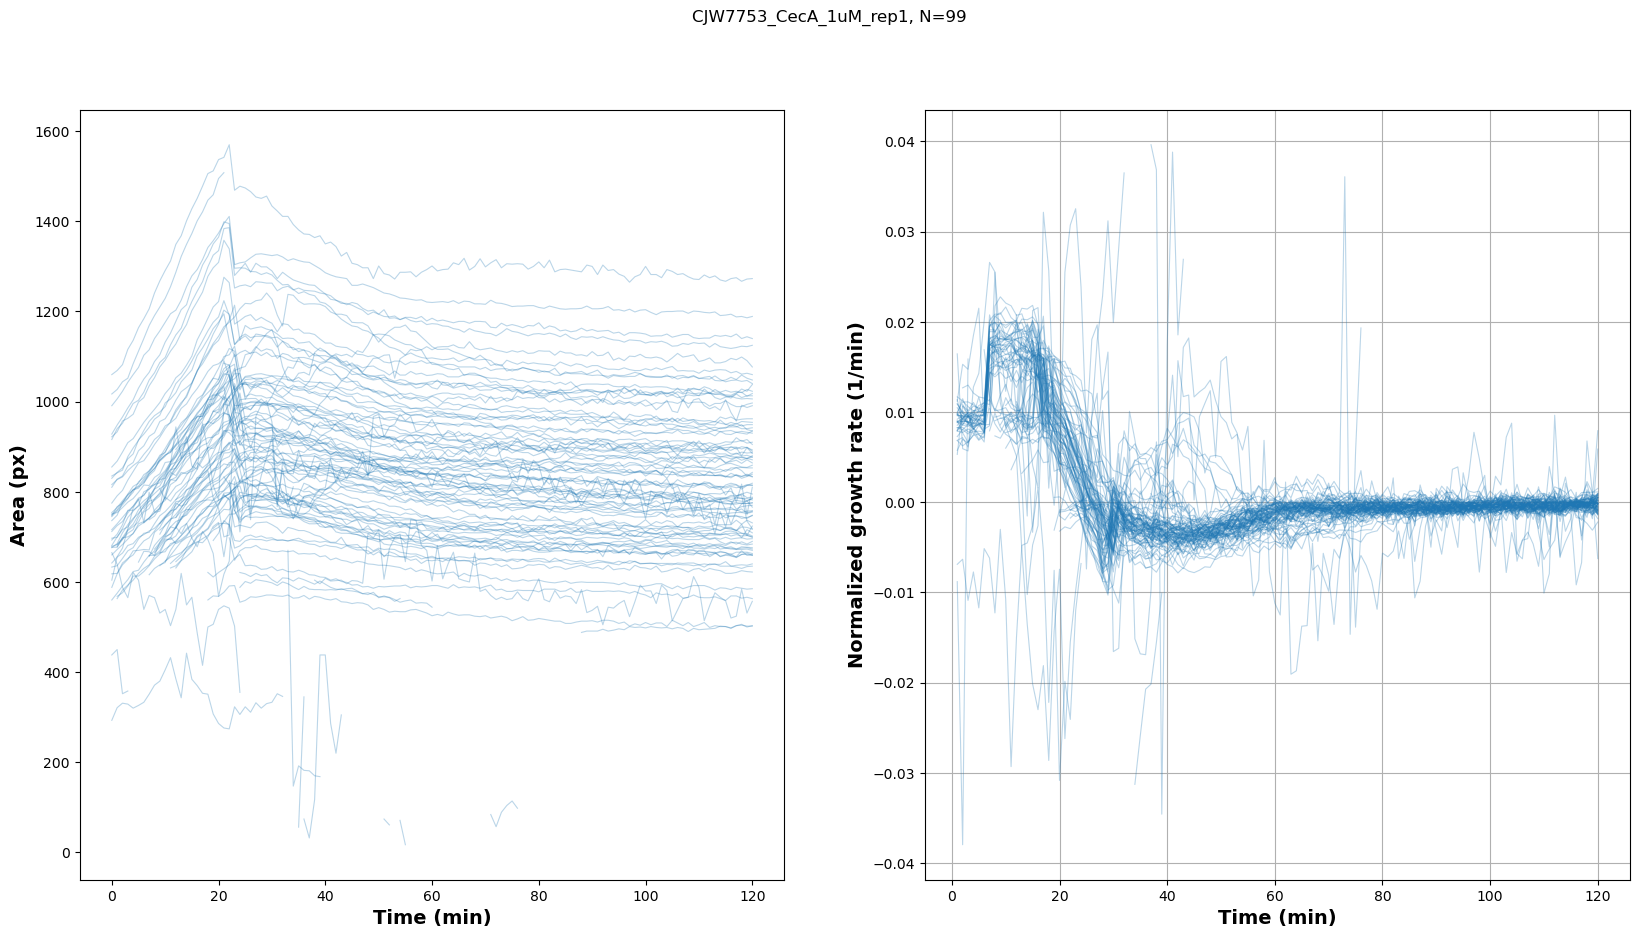

In [6]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))
ax1 = fig.add_subplot(1, 2, 1)
x_var = 'time_min'
y_var = 'area'
sns.lineplot(data=df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(1, 2, 2)
y_var = 'gr_smooth_norm'
df_2 = df[df['time_min_aligned'] > 0]

sns.lineplot(df_2, x=x_var, y=y_var, estimator=None,
             lw=0.8, alpha=0.3, units="cell_id")
plt.grid(True)
# for fr_inj in fr_inj_list:
#     plt.axvline(x = fr_inj)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized growth rate (1/min)', fontsize=14, fontweight='bold')
# plt.xlim(0,400)
plt.show()

__Continue curation of noisy trajecories, which underlie bad tracking, upon visual inspection__

In [11]:
df = curate_fast_jumps(df, gr_max=0.03, gr_min=-0.015) # eliminates cells with impossible growth rates
df = curate_short_trajectories(df, 20)    # eliminate too short trajectories < 20 frames

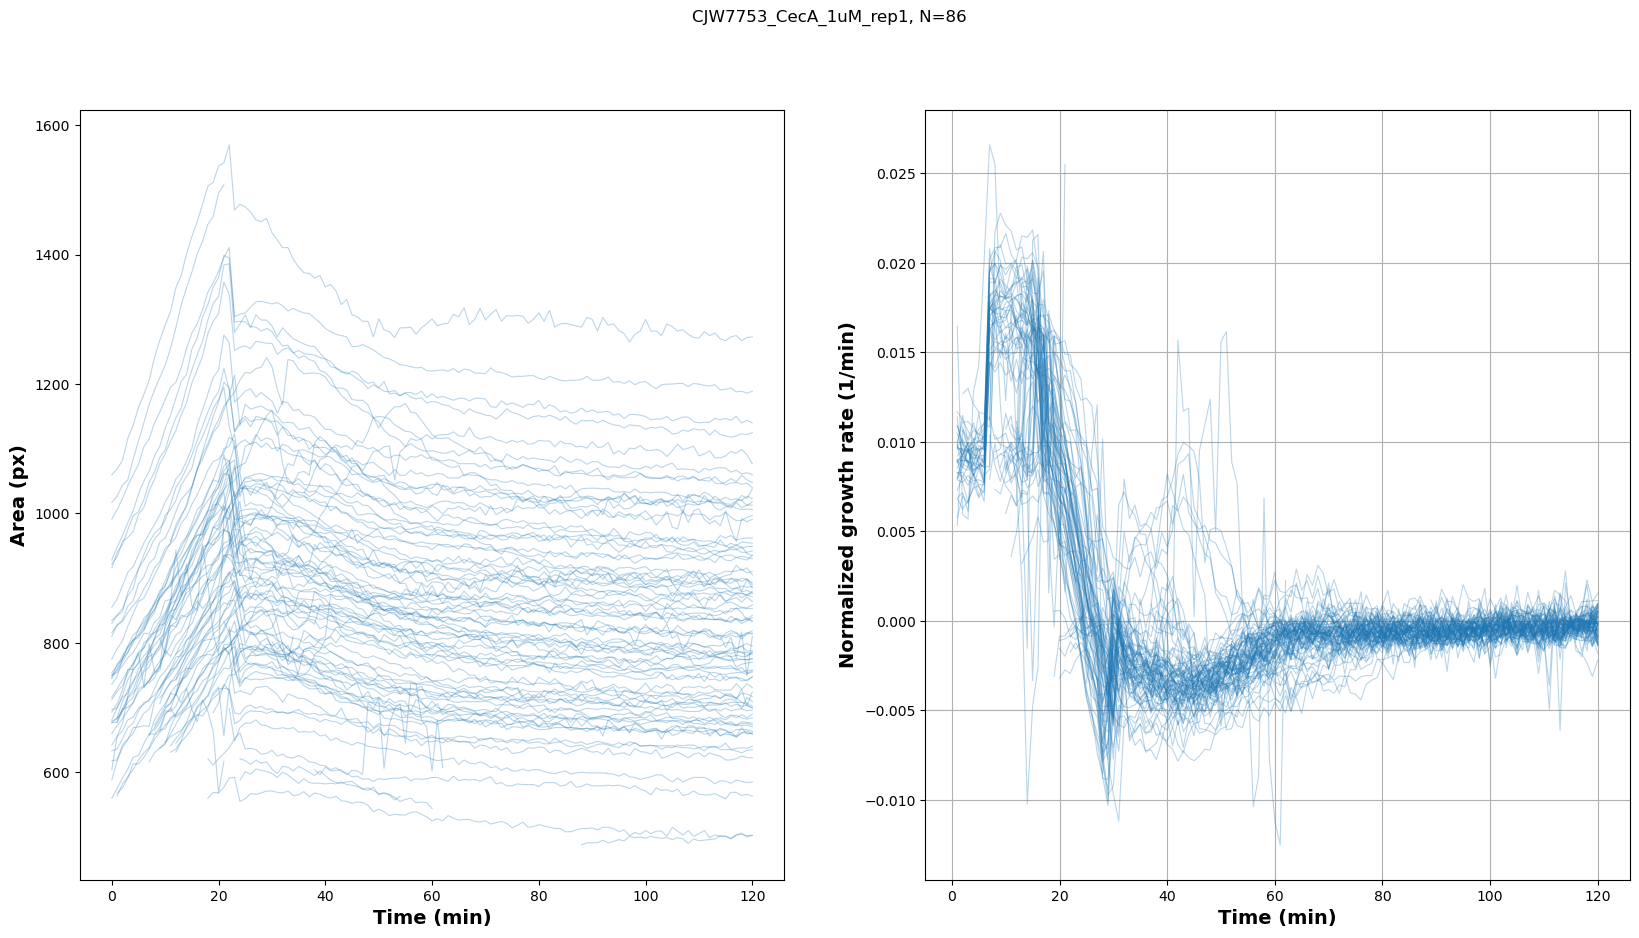

In [12]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))
ax1 = fig.add_subplot(1, 2, 1)
x_var = 'time_min'
y_var = 'area'
sns.lineplot(data=df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(1, 2, 2)
y_var = 'gr_smooth_norm'
df_2 = df[df['time_min_aligned'] > 0]

sns.lineplot(df_2, x=x_var, y=y_var, estimator=None,
             lw=0.8, alpha=0.3, units="cell_id")
plt.grid(True)
# for fr_inj in fr_inj_list:
#     plt.axvline(x = fr_inj)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized growth rate (1/min)', fontsize=14, fontweight='bold')
# plt.xlim(0,400)
plt.show()

__Curate cells that were not growing healthly from the beginning, or did not stop growing by the end of the trajectory__

In [13]:
df = curate_early_shrinkage_2(df, window=10, gr_min=0.005) # eliminate cells that in the last 10 minutes did not have the normalized gr between -0.005 and 0.005
df = curate_not_killed(df, window=10, gr_max=0.005, gr_min=-0.04)

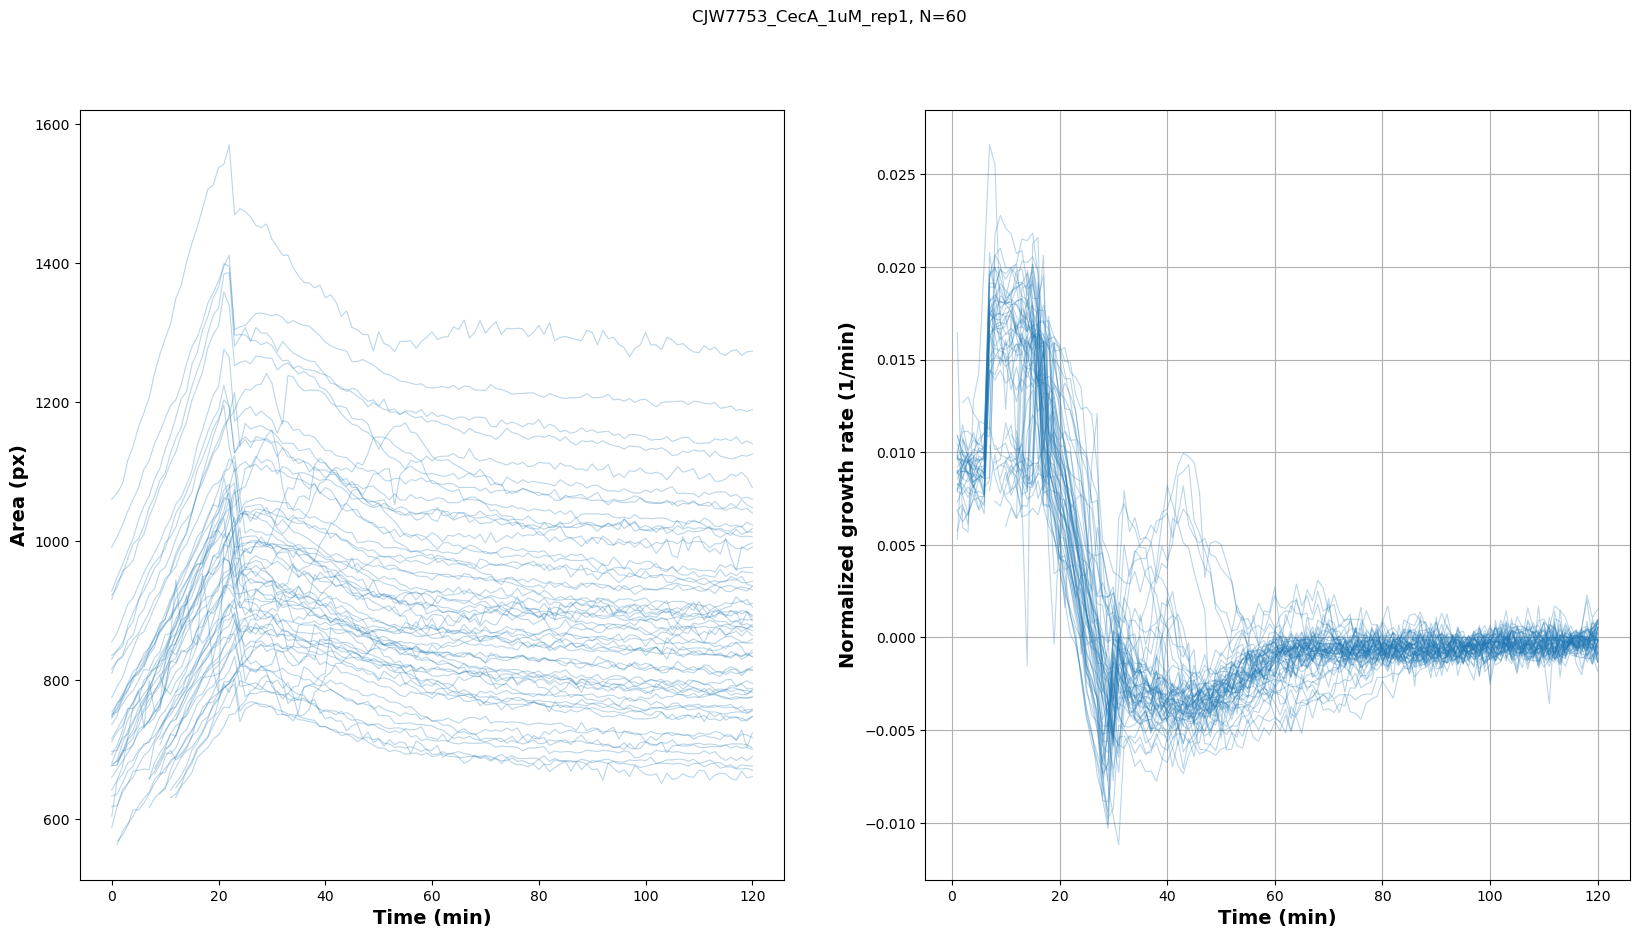

In [16]:
fig = plt.figure(figsize=(20, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))
ax1 = fig.add_subplot(1, 2, 1)
x_var = 'time_min'
y_var = 'area'
sns.lineplot(data=df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(1, 2, 2)
y_var = 'gr_smooth_norm'
df_2 = df[df['time_min_aligned'] > 0]

sns.lineplot(df_2, x=x_var, y=y_var, estimator=None,
             lw=0.8, alpha=0.3, units="cell_id")
plt.grid(True)
# for fr_inj in fr_inj_list:
#     plt.axvline(x = fr_inj)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized growth rate (1/min)', fontsize=14, fontweight='bold')
# plt.xlim(0,400)
plt.show()

__Export curated dataframes in output folder '/output_2'__

In [17]:
output_folder = 'output_2'
df_name = '_cell_features_df_first_curation'

save_dict_path = experiment_path + '/' + output_folder
if not os.path.exists(save_dict_path):
    os.makedirs(save_dict_path)

count = 0
for pos in df['xy'].unique():
    df_basename = 'xy' + pos + '_' + exp_name + df_name
    sub_df_temp = df[df['xy'] == pos]
    sub_df_temp.to_pickle(save_dict_path + '/' + df_basename + '.pkl')
    N = np.size(sub_df_temp['cell_id'].unique())
    count += N
    print('Saved df with N=' + str(N) + ' at pos ' + pos)
print('Total cells is: ' + str(count))

Saved df with N=21 at pos 08
Saved df with N=14 at pos 09
Saved df with N=25 at pos 07
Total cells is: 60
